In [97]:
# Modelo Dengue estocástico discreto (single strain) - 8 patches
import numpy as np


def _chk(name, x, low=None, high=None):
    if not np.all(np.isfinite(x)):
        i = np.where(~np.isfinite(x))[0]
        raise ValueError(f"{name}: NaN/Inf en índices {i[:10]}")
    if low is not None and np.any(x < low):
        i = np.where(x < low)[0]
        raise ValueError(f"{name}: valores < {low} en {i[:10]}, min={x.min()}")
    if high is not None and np.any(x > high):
        i = np.where(x > high)[0]
        raise ValueError(f"{name}: valores > {high} en {i[:10]}, max={x.max()}")

def sigma_v_from_temp(T, s0=1/10, k=0.03):
    return np.clip(s0 * np.exp(k*(T-25)), 1/20, 1/3)

def a_from_temp_hum(T, RH, a0=0.3, alpha_T=0.05, alpha_RH=0.5):
    # tasa de mordedura ↑ con T y con humedad (centrada en RH=0.6)
    a = a0 * (1 + alpha_T*(T - 25.0) + alpha_RH*(RH - 0.6))
    return np.clip(a, 0.0, 1.0)

def mu_v_from_temp_hum(T, RH, base=0.12, beta_T=0.03, beta_RH=-0.8):
    # mortalidad ↑ con temperaturas alejadas, ↓ con mayor RH
    mu = base * (1 + beta_T*(T - 25.0) + beta_RH*(RH - 0.6))
    return np.clip(mu, 0.05, 0.5)

def K_from_moisture(rain, RH, K0, alpha_rain, alpha_rh=1.0):
    # capacidad de carga aumenta con lluvia y humedad
    K = K0 * (1 + alpha_rain * rain + alpha_rh * (RH - 0.6))
    return np.maximum(0.0, K)

def simulate(
    days,
    Nh,            # array len P
    init_Ih,       # initial infected humans per patch
    temp, rain, hum,    # arrays shape (P, days)
    adjacency,     # P x P movement probs or adjacency
    params,
    debug=False,
):
    P = len(Nh)
    # state arrays: shape (P,)
    Sh = Nh.copy().astype(int)
    Eh = np.zeros(P, dtype=int)
    Ih = np.array(init_Ih, dtype=int)
    Rh = np.zeros(P, dtype=int)

    # vector state
    Nv = (0.05 * Nh).astype(int)  # initial vector pop ~5% of humans; tune
    Sv = Nv.copy()
    Ev = np.zeros(P, dtype=int)
    Iv = np.zeros(P, dtype=int)






    # subtract initial infected humans from susceptible
    Sh -= Ih

    # time series store
    record = {'Sh':[], 'Eh':[], 'Ih':[], 'Rh':[], 'Sv':[], 'Ev':[], 'Iv':[], 'Nv':[]}

    # precompute movement matrix (row p: prob to go to q)
    # adjacency given as list of neighbors or matrix; here assume matrix P x P with rows summing to 1
    M = adjacency.copy()



    if debug:
        # assert temp.shape == (P, days) and rain.shape == (P, days)
        assert M.shape == (P, P)
        s = M.sum(1)
        _chk("Nh", Nh, 0, None)
        _chk("init_Ih", init_Ih, 0, None)
        if not np.allclose(s, 1.0, atol=1e-12):
            i = np.where(~np.isclose(s, 1.0, atol=1e-12))[0]
            raise ValueError(f"M_row_sums fuera de 1: idx={i[:10]}, min={s.min()}, max={s.max()}")

    for t in range(days):
        T = temp[:, t]
        R = rain[:, t]
        H = (hum[:, t] if hum is not None else np.full(P, 0.6))  # baseline RH=60%

        # tasa de mordedura y FOI dependientes de T y RH
        a = a_from_temp_hum(T, H,
                            a0=params.get('a0', 0.3),
                            alpha_T=params.get('alpha_T', 0.05),
                            alpha_RH=params.get('alpha_RH_a', 0.5))

        with np.errstate(divide='ignore', invalid='ignore'):
            lambda_h = a * params['b'] * (Iv / np.maximum(1, Nv))
            lambda_v = a * params['c'] * (Ih / np.maximum(1, Nh))
        lambda_h = np.clip(np.nan_to_num(lambda_h, nan=0.0), 0.0, None)
        lambda_v = np.clip(np.nan_to_num(lambda_v, nan=0.0), 0.0, None)

        # mortalidad vectorial con T+RH
        mu_v = mu_v_from_temp_hum(T, H,
                                  base=params.get('mu_base', 0.12),
                                  beta_T=params.get('beta_T', 0.03),
                                  beta_RH=params.get('beta_RH', -0.8))

        # capacidad de carga con lluvia+humedad
        K0 = params['K0_base'] * (Nh/np.mean(Nh))
        K = K_from_moisture(R, H, K0,
                            params['alpha_rain'],
                            params.get('alpha_rh_K', 1.0))

        # update vector population via births (stochastic)
        births = np.random.poisson(np.maximum(0, K - Nv))
        Sv += births
        Nv += births

        # vector natural deaths
        deaths_v = np.random.binomial(Nv, 1 - np.exp(-mu_v))
        # remove deaths proportionally from Sv, Ev, Iv
        if Nv.sum() > 0:
            if deaths_v.sum() > 0:
                for p in range(P):
                    if Nv[p] == 0: continue
                    # split deaths into compartments proportionally
                    comps = np.array([Sv[p], Ev[p], Iv[p]], dtype=float)
                    if comps.sum() == 0:
                        Sv[p] = max(0, Sv[p] - deaths_v[p])
                    else:
                        fracs = comps / comps.sum()
                        dS = np.random.binomial(Sv[p], (deaths_v[p]*fracs[0]/max(1e-9,comps[0])))
                        # simpler: proportional remove
                        Sv[p] = max(0, Sv[p] - int(round(deaths_v[p]*fracs[0])))
                        Ev[p] = max(0, Ev[p] - int(round(deaths_v[p]*fracs[1])))
                        Iv[p] = max(0, Iv[p] - int(round(deaths_v[p]*fracs[2])))
        Nv = Sv + Ev + Iv  # refresh

        # Forces of infection
        with np.errstate(divide='ignore', invalid='ignore'):
            lambda_h = a * params['b'] * (Iv / np.maximum(1, Nv))
            lambda_v = a * params['c'] * (Ih / np.maximum(1, Nh))

        # HUMAN MOVEMENT (move people according to M)
        # For each compartment, redistribute across patches using multinomial draws
        def move_compartment(X):
            X_new = np.zeros_like(X)
            for p in range(P):
                n = X[p]
                if n <= 0: continue
                probs = M[p]
                # draw multinomial: how many from p go to each q
                moved = np.random.multinomial(n, probs)
                X_new += moved
            return X_new

        Sh = move_compartment(Sh)
        Eh = move_compartment(Eh)
        Ih = move_compartment(Ih)
        Rh = move_compartment(Rh)

        # HUMAN transitions (exposure, progression, recovery)
        newE = np.array([np.random.binomial(Sh[p], 1 - np.exp(-lambda_h[p])) for p in range(P)])
        Sh -= newE
        Eh += newE

        newI = np.array([np.random.binomial(Eh[p], 1 - np.exp(-params['sigma_h'])) for p in range(P)])
        Eh -= newI
        Ih += newI

        newR = np.array([np.random.binomial(Ih[p], 1 - np.exp(-params['gamma'])) for p in range(P)])
        Ih -= newR
        Rh += newR

        record.setdefault('newIh', []).append(newI.copy())
        # VECTOR transitions: infections (from humans), progression E->I
        newEv = np.array([np.random.binomial(Sv[p], 1 - np.exp(-lambda_v[p])) for p in range(P)])
        Sv -= newEv
        Ev += newEv
        sigma_v = sigma_v_from_temp(T)
        newIv = np.array([np.random.binomial(Ev[p], 1 - np.exp(-params['sigma_v'])) for p in range(P)])
        Ev -= newIv
        Iv += newIv

        # store
        record['Sh'].append(Sh.copy()); record['Eh'].append(Eh.copy())
        record['Ih'].append(Ih.copy()); record['Rh'].append(Rh.copy())
        record['Sv'].append(Sv.copy()); record['Ev'].append(Ev.copy())
        record['Iv'].append(Iv.copy()); record['Nv'].append(Nv.copy())

    # convert lists to arrays
    for k in record:
        record[k] = np.array(record[k])
    return record


# ejemplo:
start_date = '2024-01-01'
days = 180


In [ ]:
# === Adapter "Forecaster" para SEIR: misma interfaz que ML ===
class SEIRForecaster:
    """
    .fit(data, t_end)   -> guarda el corte temporal (sin fuga)
    .predict(h)         -> simula R corridas (h semanas) y devuelve {'mean': (h,P)}
    """
    def __init__(self, params, R=5):
        self.params = dict(params)   # b, c, sigma_h, gamma, sigma_v, K0_base, alpha_rain
        self.R = int(R)
        self.data = None
        self.t_end = None
        self.week_end = None

    def fit(self, data, t_end):
        self.data = data
        self.t_end = int(t_end)
        self.week_end = data["week_index"][self.t_end]
        return self

    def predict(self, h):
        d = self.data
        # día de arranque: siguiente al cierre de la semana t_end
        day0 = day_index_for_week_end(self.week_end, d["dates"])
        # estado inicial Ih(t0) usando tabla diaria de infecciosos
        init_Ih = infectious_on_date(d["wide"], d["dates"][day0], d["order"])
        # clima recortado al horizonte
 
        t, r,hum, h_days = climate_slice(d["temp"], d["rain"], d["hum"], day0, h)
        # simular R veces y promediar
        runs = []
        for _ in range(self.R):
            rec = simulate(h_days, d["Nh"], init_Ih, t, r,hum, d["M"], self.params, debug=False)
            runs.append(seir_weekly_from_rec(rec, 'newIh'))  # (h, P)
        yhat = np.mean(runs, axis=0)  # (h, P)
        return {"mean": yhat}


In [99]:
import pandas as pd


def infecciosos_df(casos, pre=2, post=5, group_col='municerca'):
    c = casos.assign(
        start = casos['fis'].dt.normalize() - pd.to_timedelta(pre, 'D'),
        end   = casos['fis'].dt.normalize() + pd.to_timedelta(post, 'D') + pd.Timedelta(days=1)  # fin exclusivo
    )[[group_col, 'start', 'end']]

    # eventos (+1 al inicio, -1 al fin_exclusivo)
    ev_start = c.rename(columns={'start':'fecha'})[[group_col, 'fecha']]
    ev_start['delta'] = 1
    ev_end   = c.rename(columns={'end':'fecha'})[[group_col, 'fecha']]
    ev_end['delta'] = -1
    ev = pd.concat([ev_start, ev_end], ignore_index=True)

    # tabla wide de deltas por día y grupo
    wide_delta = (ev.pivot_table(index='fecha', columns=group_col, values='delta', aggfunc='sum')
                    .sort_index()
                    .fillna(0))

    # rango completo y ceros
    idx = pd.date_range(wide_delta.index.min(), wide_delta.index.max(), freq='D')
    wide_delta = wide_delta.reindex(idx, fill_value=0)

    # cumsum por columna -> infecciosos por fecha y grupo (incluye días sin casos)
    wide = wide_delta.cumsum()
    wide.index.name = 'fecha'
    return wide.astype('int32')

import pandas as pd
df_cases=pd.read_csv(r"data\processed\diario_municerca.csv").sort_values("fis")
df_cases=df_cases.loc[~df_cases["municerca"].isnull()]
df_cases['fis'] = pd.to_datetime(df_cases['fis'], errors='coerce')

# dedup + ventanas
casos = (df_cases.drop_duplicates('ideventocaso')
           .assign(fis=pd.to_datetime(df_cases['fis'], errors='coerce'))
           .dropna(subset=['fis']))

wide = infecciosos_df(casos, pre=2, post=5, group_col='municerca')   # DataFrame ancho
# total sistema
wide['TOTAL'] = wide.sum(axis=1)

# formato largo (opcional)
long = (wide.drop(columns=['TOTAL'])
            .stack()
            .rename('infecciosos')
            .reset_index())
f_inicial="2024-01-20"
long=long.sort_values(by="municerca")
long_f=long.loc[long["fecha"]==f_inicial]

In [100]:


df=pd.read_excel(r"data\external\Indicadores sociodemograficos\Indicadores_MundoSano.xlsx").sort_values(by="municerca")

df2=df[["municerca","Estimación poblacional"]]

Nh=df2['Estimación poblacional'].to_numpy(dtype=int)   # -> array([...])

init_Ih=long_f['infecciosos'].to_numpy(dtype=int)   # -> array([...])


In [101]:
df_clima=pd.read_csv("data\processed\clima_processed.csv")
df_clima
import pandas as pd
import numpy as np

def build_matrix(df, value_col, start_date, days, patch_col='municerca', date_col='date'):
    # fechas objetivo
    idx = pd.date_range(pd.to_datetime(start_date).normalize(), periods=days, freq='D')

    # tipos
    g = df.copy()
    g[date_col] = pd.to_datetime(g[date_col]).dt.normalize()

    # elegí el conjunto y orden de patches
    patches = (g[patch_col].dropna().unique().tolist())   # o tu orden preferido

    # filtro por rango y pivoteo -> (days x P)
    tbl = (g.loc[g[date_col].between(idx.min(), idx.max())]
             .pivot_table(index=date_col, columns=patch_col, values=value_col, aggfunc='mean')
             .reindex(idx))                 # asegura todas las fechas

    # completa faltantes (interpolar por columna y ffill/bfill de respaldo)
    tbl = tbl.interpolate(limit_direction='both').ffill().bfill()

    # reordená/seleccioná columnas y exportá
    tbl = tbl.reindex(columns=patches)
    arr = tbl.to_numpy().T.astype(float)    # -> (P, days)
    return arr, patches, idx

days_c=560
temp, patches, dates = build_matrix(df_clima, 't2m', start_date, days_c)  # (P, days)
rain, _, _            = build_matrix(df_clima, 'tp',  start_date, days_c)  # idem


def rh_from_t2m_d2m(df, t_col='t2m', td_col='d2m'):
    # Magnus (°C): RH = e(Td)/e(T)
    def e_s(T): return np.exp((17.625*T)/(243.04+T))
    RH = e_s(df[td_col].astype(float)) / e_s(df[t_col].astype(float))
    return RH.clip(0, 1)

df_clima['rh'] = rh_from_t2m_d2m(df_clima, 't2m', 'd2m')
hum, _, _ = build_matrix(df_clima, 'rh', start_date, days_c)

P = temp.shape[0]
assert temp.shape == (P, days_c) and rain.shape == (P, days_c)


<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Nainh\AppData\Local\Temp\ipykernel_9684\2054830225.py:1: SyntaxWarning: invalid escape sequence '\p'
  df_clima=pd.read_csv("data\processed\clima_processed.csv")


In [102]:
# === helpers para iniciar en cada ventana/horizonte ===
def infectious_on_date(wide_df, date, order):
    """vector Ih(t0) por zona en 'order' para la fecha diaria 'date'."""
    row = wide_df.reindex([pd.to_datetime(date).normalize()]).fillna(0.0)
    row = row.reindex(columns=order, fill_value=0.0).iloc[0]
    return row.to_numpy(dtype=int)

def day_index_for_week_end(week_end, daily_index):
    """índice (int) del día siguiente al cierre de la semana 'week_end' dentro del índice diario 'daily_index'."""
    week_end = pd.to_datetime(week_end).normalize()
    i = np.searchsorted(daily_index.values, week_end.to_datetime64())
    return int(i + 1)  # empezar al día siguiente

def climate_slice(temp, rain, hum, day0, h_weeks):
    h_days = 7 * int(h_weeks)
    t = temp[:, day0:day0+h_days]
    r = rain[:, day0:day0+h_days]
    hu = hum[:, day0:day0+h_days]
    if t.shape[1] < h_days or r.shape[1] < h_days:
        raise ValueError("Clima insuficiente para el horizonte pedido.")
    return t, r,hu, h_days


In [103]:
# ===== Example setup =====
P = 8

# Nh = np.array([20000]*P)  # ejemplo: cada patch 20k habitantes; reemplazar con datos reales
# init_Ih = np.zeros(P, int); init_Ih[0] = 5  # semilla en patch 0
# temp = 25 + 3*np.random.randn(P, days)  # ejemplo sintético
# rain = np.abs(np.random.randn(P, days))  # mm normalizado; reemplazar con series reales

# adjacency: ejemplo simple de línea con movimiento a vecinos y quedarse
M = np.zeros((P,P))
for p in range(P):
    neighbors = []
    if p-1 >= 0: neighbors.append(p-1)
    neighbors.append(p)
    if p+1 < P: neighbors.append(p+1)
    # distribuir probabilidades
    probs = np.zeros(P)
    probs[neighbors] = 1.0/len(neighbors)
    M[p] = probs

base_params = {
    'b': 0.4,
    'c': 0.5,
    'sigma_h': 1/5.0,    # incubation human
    'gamma': 1/5.0,      # recovery
    'sigma_v': 1/10.0,   # EIP
    'K0_base': 500.0,    # base carrying capacity scale (tune)
    'alpha_rain': 0.6
}

base_params.update({
    # a(T,RH)
    "a0": 0.3, "alpha_T": 0.05, "alpha_RH_a": 0.5,
    # mu_v(T,RH)
    "mu_base": 0.12, "beta_T": 0.03, "beta_RH": -0.8,
    # K(rain, RH)
    "alpha_rh_K": 1.0,
})

rec = simulate(days, Nh, init_Ih, temp, rain, hum, M, base_params, debug=True)



In [104]:
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.special import gammaln

# ---------- 1) Observado semanal por FIS (weeks x P) ----------
def obs_weekly(df_cases, order, start_date, days, week='W-SUN'):
    d = (df_cases.drop_duplicates('ideventocaso')
                 .assign(fis=pd.to_datetime(df_cases['fis']).dt.normalize()))
    idx = pd.date_range(pd.to_datetime(start_date).normalize(), periods=days, freq='D')
    g = (d[d['fis'].between(idx[0], idx[-1])]
           .groupby(['fis','municerca'])['ideventocaso'].nunique()
           .unstack('municerca')
           .reindex(idx).fillna(0.0))
    w = g.resample(week).sum()
    y = w.reindex(columns=order).to_numpy()  # (weeks, P)
    return y, w.index

# ---------- 2) Incidencia semanal simulada promedio (weeks x P) ----------
def sim_weekly(theta, R=5):
    b, c, K0_base, alpha = theta
    params = base_params.copy()
    params.update(b=b, c=c, K0_base=K0_base, alpha_rain=alpha)

    runs = []
    for _ in range(R):
        rec = simulate(days, Nh, init_Ih, temp, rain, hum, M, params)
        Ih, Rh = rec['Ih'], rec['Rh']                # (days, P)
        inc = np.diff(Ih, axis=0) + np.diff(Rh, axis=0)   # (days-1, P)
        inc = np.vstack([np.zeros((1, inc.shape[1])), inc])  # (days, P) alineado a días
        W = (inc.shape[0] // 7)
        inc_w = inc[:W*7].reshape(W, 7, inc.shape[1]).sum(axis=1)  # (weeks, P)
        runs.append(inc_w)
    lam = np.mean(runs, axis=0) + 1e-6  # media como intensidad Poisson
    return lam

# ---------- 3) Función objetivo: NLL Poisson ----------
def poisson_nll(lam, y):
    # lam,y: (weeks, P)
    return np.sum(lam - y*np.log(lam) + gammaln(y+1))

def make_objective(y):
    def obj(theta):
        lam = sim_weekly(theta, R=5)
        W = min(lam.shape[0], y.shape[0])
        return poisson_nll(lam[:W], y[:W])
    return obj


order=list(df_cases.sort_values("municerca")["municerca"].unique())
y_obs, week_index = obs_weekly(df_cases, order, start_date, days)
objective = make_objective(y_obs)


In [105]:
import numpy as np
from scipy.optimize import differential_evolution
from scipy.special import gammaln

base_params = dict(
    b=0.3, c=0.5, sigma_h=1/5, gamma=1/5, sigma_v=1/10, K0_base=500.0, alpha_rain=0.6
)


base_params.update({
    # a(T,RH)
    "a0": 0.3, "alpha_T": 0.05, "alpha_RH_a": 0.5,
    # mu_v(T,RH)
    "mu_base": 0.12, "beta_T": 0.03, "beta_RH": -0.8,
    # K(rain, RH)
    "alpha_rh_K": 1.0,
})

def weekly_from_rec(rec):
    Ih, Rh = rec['Ih'], rec['Rh']            # (days, P)
    inc = np.diff(Ih, axis=0) + np.diff(Rh, axis=0)  # (days-1, P)
    inc = np.vstack([np.zeros((1, inc.shape[1])), inc])  # alinear a días
    W = inc.shape[0] // 7
    return inc[:W*7].reshape(W, 7, inc.shape[1]).sum(axis=1)  # (weeks, P)

def sim_weekly(theta, R=3):
    b, c, K0_base, alpha = theta
    params = base_params.copy()
    params.update(b=float(b), c=float(c), K0_base=float(K0_base), alpha_rain=float(alpha))

    runs = []
    for _ in range(R):
        rec = simulate(days, Nh, init_Ih, temp, rain, hum, M, params)
        runs.append(weekly_from_rec(rec))
    lam = np.mean(runs, axis=0)
    # seguridad numérica
    lam = np.clip(lam, 1e-9, None)
    return lam

def poisson_nll(lam, y):
    return np.sum(lam - y*np.log(lam) + gammaln(y+1))

def make_objective(y):
    def obj(theta):
        try:
            lam = sim_weekly(theta, R=3)
            W = min(lam.shape[0], y.shape[0])
            return float(poisson_nll(lam[:W], y[:W]))
        except Exception as e:
            # Si algo explota (shapes, NaNs, etc.), penalizá fuerte
            return 1e15
    return obj
objective = make_objective(y_obs)

# sanity check:
val = objective([0.3, 0.5, 500.0, 0.6])
print("obj @ start:", val)   # debe ser número finito

obj @ start: 35673.47863342995


In [106]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def load_and_fix_M(csv_path, order, min_stay=0.0, atol=1e-9):
    df = pd.read_csv(csv_path, index_col=0)
    # alinear al orden de parches
    missing = set(order) - set(df.index)
    if missing:
        raise ValueError(f"Faltan zonas en el CSV: {sorted(missing)[:10]}")
    df = df.reindex(index=order, columns=order).fillna(0.0)

    M = df.to_numpy(float)
    # limpiar valores raros
    M[~np.isfinite(M)] = 0.0
    M[M < 0] = 0.0

    # asegurar estadía mínima si querés
    if min_stay > 0:
        np.fill_diagonal(M, np.maximum(np.diag(M), min_stay))

    # filas muertas -> identidad (se quedan en su parche)
    rs = M.sum(1, keepdims=True)
    dead = (rs[:, 0] == 0.0)
    if dead.any():
        M[dead, :] = 0.0
        M[dead, dead] = 1.0
        rs = M.sum(1, keepdims=True)

    # normalizar filas
    M = M / rs

    # clip numérico y normalización fina (por redondeo)
    M = np.clip(M, 0.0, 1.0)
    M /= M.sum(1, keepdims=True)

    # reporte de filas que no cierran dentro de tolerancia
    bad = np.where(~np.isclose(M.sum(1), 1.0, atol=atol))[0]
    if bad.size:
        print(f"[AVISO] {bad.size} filas no suman 1 dentro de atol={atol}. max desvío=",
              np.max(np.abs(M.sum(1)-1.0)))

    return M

# ----- EJEMPLO DE USO -----
# order debe ser la lista de zonas en el mismo orden que tus vectores Nh, init_Ih, etc.
# por ejemplo si lo tomás de tu GeoDataFrame de zonas:
# order = list(zones["zona"])
# o si lo tenés en un DF de población:
# order = list(pop_df["municerca"])

# M = load_and_fix_M("mobility_prob_matrix.csv", order=order, min_stay=0.05)

rec = simulate(days, Nh, init_Ih, temp, rain, hum, M, base_params,debug=True)

rec

{'Sh': array([[ 4743,  8454,  9226, ..., 12382, 22128, 18768],
        [ 5082,  8349,  9433, ..., 14831, 20900, 16718],
        [ 5342,  8334,  9344, ..., 15458, 20410, 15365],
        ...,
        [ 8693, 13135, 13009, ..., 13073, 13178,  8718],
        [ 8525, 13256, 13054, ..., 13118, 13069,  8756],
        [ 8798, 12873, 13183, ..., 13147, 13178,  8740]], shape=(180, 8)),
 'Eh': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [2, 4, 2, ..., 5, 0, 0],
        [1, 3, 1, ..., 2, 2, 0],
        [0, 3, 2, ..., 1, 1, 0]], shape=(180, 8)),
 'Ih': array([[0, 0, 1, ..., 2, 1, 1],
        [0, 0, 1, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 0],
        ...,
        [5, 4, 5, ..., 2, 4, 0],
        [6, 4, 4, ..., 6, 1, 1],
        [4, 2, 8, ..., 1, 3, 1]], shape=(180, 8)),
 'Rh': array([[ 0,  0,  0, ...,  0,  2,  1],
        [ 0,  0,  0, ...,  0,  2,  2],
        [ 0,  0,  0, ...,  1,  1,  2],
        ...,
        [19, 38

In [107]:

from pathlib import Path
import json
import numpy as np
from scipy.optimize import differential_evolution

CACHE = Path("fit_params.json")

def run_fit():
    bounds = [(0.05,0.6),(0.2,0.8),(100.0,20000.0),(0.0,2.0)]
    res = differential_evolution(objective, bounds, popsize=12, maxiter=40, tol=1e-2, seed=0)
    payload = {
        "x": res.x.tolist(),
        "fun": float(res.fun),
        "bounds": bounds,
        "nit": int(res.nit),
        "seed": 0,
    }
    CACHE.write_text(json.dumps(payload, indent=2))
    return np.array(payload["x"]), payload["fun"]

def load_or_fit(force=False):
    if not force and CACHE.exists():
        d = json.loads(CACHE.read_text())
        return np.array(d["x"]), float(d["fun"])
    return run_fit()

# x_opt, fval = load_or_fit()            # lee de JSON si existe
# # res = differential_evolution(objective, bounds, popsize=12, maxiter=40, tol=1e-2, seed=0)  # sin workers
# print(x_opt, fval) #array([5.19052844e-01, 4.30579009e-01, 2.75900123e+02, 2.26056206e-04])
#[4.51712591e-01 7.86586738e-01 6.85159825e+02 3.21372836e-04] 3421.29263858315

In [108]:
# import numpy as np
# from scipy.special import gammaln

# # --- helpers ---
# def align(y, lam):
#     W = min(y.shape[0], lam.shape[0])
#     return y[:W], lam[:W]

# def poisson_nll(lam, y):
#     lam = np.clip(lam, 1e-9, None)
#     return float(np.sum(lam - y*np.log(lam) + gammaln(y+1)))

# def rmse_overall(lam, y):
#     # RMSE sobre todas las celdas (weeks×P)
#     return float(np.sqrt(np.mean((lam - y)**2)))

# def rmse_by_patch(lam, y):
#     # vector de RMSE por parche
#     return np.sqrt(np.mean((lam - y)**2, axis=0))

# def rmse_weekly_totals(lam, y):
#     # RMSE de totales semanales agregados (suma sobre parches)
#     return float(np.sqrt(np.mean((lam.sum(axis=1) - y.sum(axis=1))**2)))

# # --- predicciones promedio para reducir ruido estocástico ---
# best_theta = res.x
# base_theta = [base_params['b'], base_params['c'],
#               base_params['K0_base'], base_params['alpha_rain']]

# lam_best = sim_weekly(best_theta, R=10)   # (weeks, P)
# lam_base = sim_weekly(base_theta, R=10)

# y, lam_best = align(y_obs, lam_best)
# _, lam_base = align(y_obs, lam_base)

# # --- métricas ---
# nll_best = poisson_nll(lam_best, y)
# nll_base = poisson_nll(lam_base, y)

# rmse_best = rmse_overall(lam_best, y)
# rmse_base = rmse_overall(lam_base, y)

# rmse_best_by_patch = rmse_by_patch(lam_best, y)
# rmse_base_by_patch = rmse_by_patch(lam_base, y)

# rmse_best_tot = rmse_weekly_totals(lam_best, y)
# rmse_base_tot = rmse_weekly_totals(lam_base, y)

# print("Poisson NLL  best:", nll_best)
# print("Poisson NLL  base:", nll_base)
# print("RMSE overall best:", rmse_best)
# print("RMSE overall base:", rmse_base)
# print("RMSE totals  best:", rmse_best_tot)
# print("RMSE totals  base:", rmse_base_tot)
# print("RMSE por parche (best):", rmse_best_by_patch)
# print("RMSE por parche (base):", rmse_base_by_patch)
# def make_objective_rmse(y):
#     def obj(theta):
#         try:
#             lam = sim_weekly(theta, R=3)
#             y_, lam_ = align(y, lam)
#             return rmse_overall(lam_, y_)
#         except Exception:
#             return 1e15
#     return obj

# objective_rmse = make_objective_rmse(y_obs)

# # res_rmse = differential_evolution(objective_rmse, bounds, popsize=12, maxiter=40, tol=1e-2, seed=0)  # sin workers
# # res_rmse.x

In [109]:
import pandas as pd
import numpy as np

def obs_weekly(df_cases, order, start_date, days, week_freq='W-SUN'):
    # normaliza fechas y dedup casos
    d = (df_cases.drop_duplicates('ideventocaso')
                  .assign(fis=pd.to_datetime(df_cases['fis']).dt.normalize()))
    # índice diario objetivo
    idx = pd.date_range(pd.to_datetime(start_date).normalize(), periods=days, freq='D')
    # panel diario (days × P) y resample a semanas
    daily = (d[d['fis'].between(idx[0], idx[-1])]
               .groupby(['fis','municerca'])['ideventocaso'].nunique()
               .unstack('municerca')
               .reindex(idx)
               .fillna(0.0)
               .reindex(columns=order, fill_value=0.0))
    weekly = daily.resample(week_freq).sum()              # (W × P)
    return weekly.to_numpy(), weekly.index                # y_obs, week_index
def seir_weekly_from_rec(rec):
    # rec['Ih'], rec['Rh']: (days × P)
    Ih, Rh = rec['Ih'], rec['Rh']
    inc = np.diff(Ih, axis=0) + np.diff(Rh, axis=0)      # (days-1 × P)
    inc = np.vstack([np.zeros((1, inc.shape[1])), inc])  # alinear a días: (days × P)
    W = inc.shape[0] // 7
    return inc[:W*7].reshape(W, 7, inc.shape[1]).sum(axis=1)  # (weeks × P)

def seir_weekly_from_rec(rec, key='newIh'):
    inc = np.asarray(rec[key])            # (days, P)  no-negativo
    W = inc.shape[0] // 7
    return inc[:W*7].reshape(W, 7, inc.shape[1]).sum(axis=1)  # (weeks, P)


In [110]:
# insumos que ya tenés
# order = list(pop_df['municerca'])     # orden de parches (columnas)


# observado
y_obs, week_index = obs_weekly(df_cases, order, start_date, days)

 
params={'b': 4.51712591e-01,
 'c': 7.86586738e-01 ,
 'sigma_h': 0.2,
 'gamma': 0.2,
 'sigma_v': 0.1,
 'K0_base': 6.85159825e+02 ,
 'alpha_rain': 3.21372836e-04,}


base_params.update({
    # a(T,RH)
    "a0": 0.3, "alpha_T": 0.05, "alpha_RH_a": 0.5,
    # mu_v(T,RH)
    "mu_base": 0.12, "beta_T": 0.03, "beta_RH": -0.8,
    # K(rain, RH)
    "alpha_rh_K": 1.0,
})

# SEIR (promediado si querés reducir ruido)
R = 10
seir_runs = []
for _ in range(10):
    rec = simulate(days, Nh, init_Ih, temp, rain, hum, M, base_params)
    seir_runs.append(seir_weekly_from_rec(rec, 'newIh'))
lam_seir = np.mean(seir_runs, axis=0)
W = min(y_obs.shape[0], lam_seir.shape[0])
y_obs   = y_obs[:W]
lam_seir= lam_seir[:W]


In [111]:

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_poisson_deviance

def metrics_block(y, yhat):
    W = min(y.shape[0], yhat.shape[0])
    y, yhat = y[:W], yhat[:W]
    tot_y, tot_hat = y.sum(axis=1), yhat.sum(axis=1)  # totales por semana

    m = {
        "RMSE_all":  float(np.sqrt(mean_squared_error(y.ravel(), yhat.ravel()))),
        "MAE_all":   float(mean_absolute_error(y.ravel(), yhat.ravel())),
        "PoissDev_all": float(mean_poisson_deviance(y.ravel(), np.clip(yhat.ravel(), 1e-9, None))),
        "RMSE_tot":  float(np.sqrt(mean_squared_error(tot_y, tot_hat))),
        "MAE_tot":   float(mean_absolute_error(tot_y, tot_hat)),
        "PoissDev_tot": float(mean_poisson_deviance(tot_y, np.clip(tot_hat, 1e-9, None))),
    }
    # RMSE por parche
    rmse_p = np.sqrt(((y - yhat)**2).mean(axis=0))
    m.update({f"RMSE_p{j}": float(v) for j, v in enumerate(rmse_p)})
    return m

# ------- elegí el bloque de test -------
# Ejemplo: últimas 8 semanas como test
H = 8
W = min(y_obs.shape[0], lam_seir.shape[0])
t0 = W - H

y_test    = y_obs[t0:W]
seir_hat  = lam_seir[t0:W]
weeks_ts  = week_index[t0:W]  # por si querés etiquetar/plotear

# métricas SEIR
m_seir = metrics_block(y_test, seir_hat)
print("SEIR:", m_seir)

SEIR: {'RMSE_all': 6.289611971338137, 'MAE_all': 4.8890625, 'PoissDev_all': 11.758692811417099, 'RMSE_tot': 47.24191729809449, 'MAE_tot': 38.8625, 'PoissDev_tot': 82.7364224184031, 'RMSE_p0': 6.46964063917, 'RMSE_p1': 7.498583199511758, 'RMSE_p2': 6.358557226289625, 'RMSE_p3': 5.853951656787062, 'RMSE_p4': 6.192233038250419, 'RMSE_p5': 6.186982301574815, 'RMSE_p6': 5.481559996935179, 'RMSE_p7': 6.084303575595157}


In [112]:
print("y_obs shape:", y_obs.shape)          # (weeks, P?)
print("lam_seir shape:", lam_seir.shape)    # (weeks, P?)
print("P_obs,P_seir:", y_obs.shape[1], lam_seir.shape[1])

#'RMSE_tot': 29.38647648153824,


y_obs shape: (25, 8)
lam_seir shape: (25, 8)
P_obs,P_seir: 8 8


In [113]:
# === métricas y evaluación rolling-origin iguales que en ML ===
import numpy as np

def poisson_deviance(y, mu, eps=1e-9):
    y = np.asarray(y, float); mu = np.asarray(mu, float)
    return 2*np.sum(y*np.log((y+eps)/(mu+eps)) - (y-mu))

def rmse_w(y, mu, w):
    return np.sqrt(np.average((y-mu)**2, weights=w))





def eval_rolling_seir(forecaster, data, windows, horizons=(1,2,4)):
    import numpy as np
    rows = []
    Y = np.asarray(data["y_obs"], float)  # (W,P)
    peak_thr = np.percentile(Y.sum(axis=1), 90) if Y.size else 0.0

    for t_end in windows:
        forecaster.fit(data, int(t_end))
        for h in horizons:
            pred = forecaster.predict(int(h))
            yhat = np.asarray(pred["mean"], float)      # (h,P)
            yobs = np.asarray(Y[t_end:t_end+h], float)  # (h,P)
            if yobs.shape[0] != h:
                continue

            # --- métricas ---
            eps = 1e-9
            # Poisson deviance total
            poiss = 2*np.sum(yobs*np.log((yobs+eps)/(yhat+eps)) - (yobs-yhat))

            # RMSE ponderado por INCIDENCIA SEMANAL (pesos 1D: h,)
            err2 = (yobs - yhat)**2                # (h,P)
            mse_week = err2.mean(axis=1)           # (h,) promedio sobre zonas
            w_week = yobs.sum(axis=1) + 1e-9       # (h,)
            rmse_w = float(np.sqrt(np.average(mse_week, weights=w_week)))

            # RMSE en picos (semanas con total >= p90)
            mask_peak = (yobs.sum(axis=1) >= peak_thr)
            rmse_peak = (float(np.sqrt(mse_week[mask_peak].mean()))
                         if mask_peak.any() else np.nan)

            rows.append({
                "t_end": int(t_end),
                "h": int(h),
                "poiss": float(poiss),
                "rmse_w": rmse_w,
                "rmse_peak": rmse_peak,
            })
    return rows




In [114]:
# === empaquetar insumos compartidos ===
data = {
    "y_obs": y_obs,          # (W,P) desde obs_weekly(...)
    "week_index": week_index,# índice semanal (DatetimeIndex)
    "order": order,          # orden de zonas
    "Nh": Nh,                # población por zona
    "M": M,                  # matriz de movilidad P×P (fila-normalizada)
    "temp": temp,            # (P, days) diario
    "rain": rain,            # (P, days) diario
    "hum": hum,            # (P, days) diario
    "dates": dates,          # índice diario (DatetimeIndex) alineado a temp/rain
    "wide": wide,            # infecciosos diarios por zona (DataFrame ancho)
}

# === ventanas y corrida rolling-origin ===
horizons = (1,2,4)
windows = list(range(36, len(week_index) - max(horizons)))  # historia mínima 52

seir_cfg = {
    "b": params['b'], "c": params['c'],
    "sigma_h": params['sigma_h'], "gamma": params['gamma'],
    "sigma_v": params['sigma_v'],
    "K0_base": params['K0_base'], "alpha_rain": params['alpha_rain'],
}

horizons = (1,2,4)
max_h = max(horizons)

def valid_windows_with_climate(data, windows, max_h):
    D = data["temp"].shape[1]        # cantidad de días de clima
    ok = []
    for t_end in windows:
        week_end = data["week_index"][t_end]
        day0 = day_index_for_week_end(week_end, data["dates"])  # día siguiente al cierre de la semana
        if day0 + 7*max_h <= D:
            ok.append(t_end)
    return ok

# define ventanas y filtralas
windows = list(range(18, len(week_index)))             # o 52 si tenés historia
windows = valid_windows_with_climate(data, windows, max_h)

print(f"ventanas válidas: {len(windows)} de {len(week_index)} semanas")

seir_scores = eval_rolling_seir(SEIRForecaster(seir_cfg, R=10), data, windows, horizons)
df_seir = pd.DataFrame(seir_scores)
print(df_seir.groupby("h")[['poiss','rmse_w','rmse_peak']].mean().round(3))


seir_scores = eval_rolling_seir(SEIRForecaster(seir_cfg, R=10), data, windows, horizons)
import pandas as pd
df_seir = pd.DataFrame(seir_scores)
print(df_seir.groupby("h")[["poiss","rmse_w","rmse_peak"]].mean().round(3))
df_seir.to_csv("results/seir_rolling_metrics.csv", index=False)


ventanas válidas: 8 de 26 semanas
{'y_obs': array([[  0.,   1.,   0.,   0.,   0.,   2.,   2.,   2.],
       [  0.,   0.,   3.,   2.,   4.,   3.,   0.,   1.],
       [  0.,   0.,   1.,   1.,   1.,   2.,   1.,   4.],
       [  1.,   1.,   0.,   0.,   2.,   6.,   2.,   5.],
       [  1.,   2.,   1.,   1.,   1.,   4.,   3.,   2.],
       [  1.,   2.,   5.,   5.,  17.,   8.,  18.,   8.],
       [  3.,   1.,   9.,   3.,  16.,  19.,  16.,  18.],
       [  4.,   2.,  10.,   2.,   7.,  14.,   8.,  10.],
       [  3.,   4.,   4.,   7.,   7.,  18.,  11.,  14.],
       [  5.,   2.,   7.,   4.,  10.,  16.,  18.,  15.],
       [ 12.,   8.,  14.,  10.,  18.,  21.,  26.,  31.],
       [ 15.,  12.,  23.,  17.,  25.,  24.,  28.,  24.],
       [ 17.,  18.,  39.,  14.,  18.,  28.,  28.,  41.],
       [ 93.,  55., 113.,  44., 102., 120., 121., 110.],
       [101.,  73., 128.,  64.,  92., 147., 162., 136.],
       [ 12.,  16.,  43.,  22.,  28.,  27.,  31.,  52.],
       [  6.,   8.,  19.,  11.,  11.,   9., 

In [115]:
(len(df_clima["date"].unique())/365-len(df_clima["date"].unique())//365)*365

263.9999999999999

In [117]:
# import pandas as pd

# def windows_diag(data, horizons, start=40):
#     W = len(data["week_index"])
#     D = data["temp"].shape[1]
#     max_h = max(horizons)
#     rows=[]
#     for t_end in range(start, W):
#         week_end = data["week_index"][t_end]
#         day0 = day_index_for_week_end(week_end, data["dates"])   # día siguiente al cierre semanal
#         rem = D - day0
#         day0_date = data["dates"][min(day0, len(data["dates"])-1)]
#         rows.append({
#             "t_end": t_end,
#             "week_end": str(week_end.date()),
#             "day0_date": str(day0_date.date()),
#             "remaining_climate_days": rem,
#             "needed_days": 7*max_h,
#             "valid": rem >= 7*max_h
#         })
#     return pd.DataFrame(rows)

# diag = windows_diag(data, horizons, start=38)
# print(diag.tail(10))
# print(diag["valid"].value_counts())
# print("climate_last_day:", data["dates"][-1].date())
# print("last_week_index:", data["week_index"][-1].date())
# print("last valid t_end:", diag[diag["valid"]]["t_end"].max())

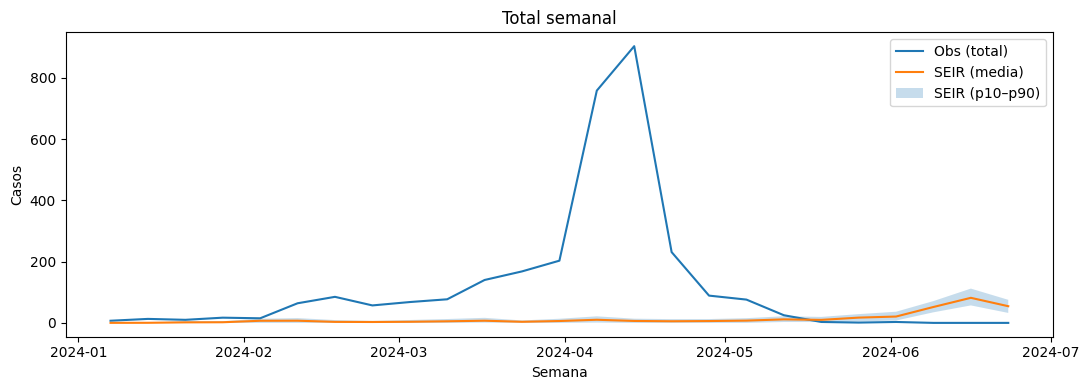

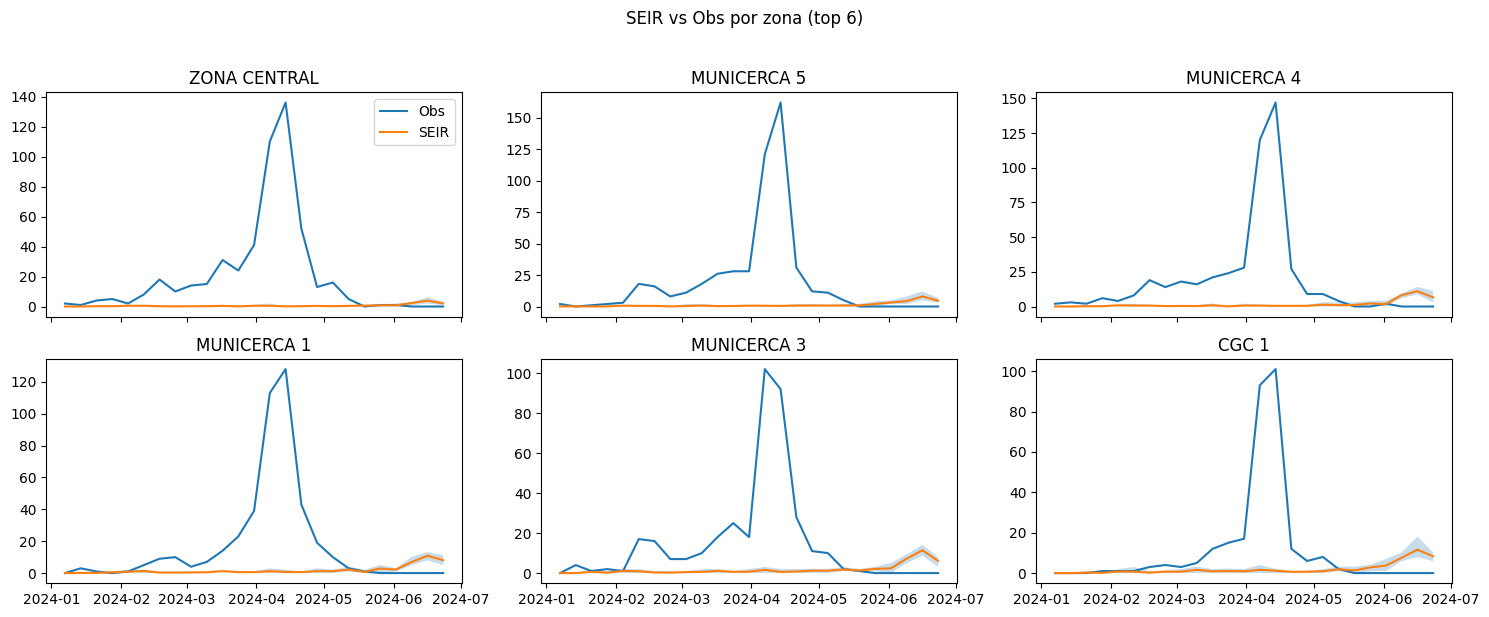

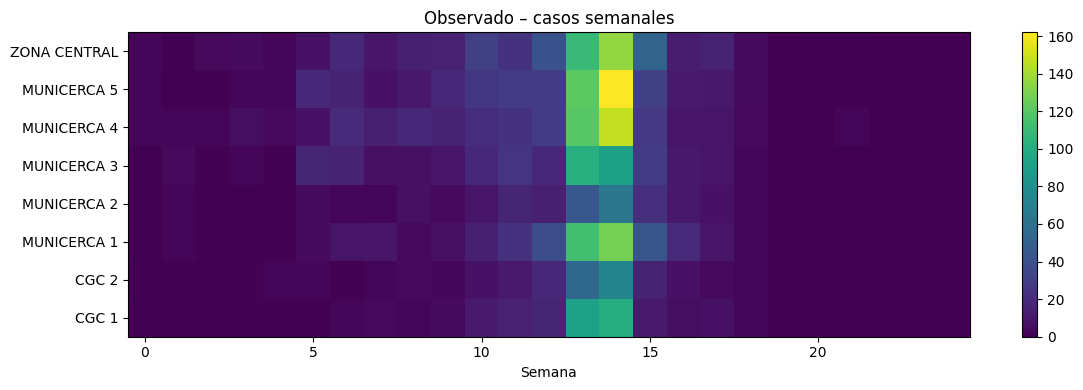

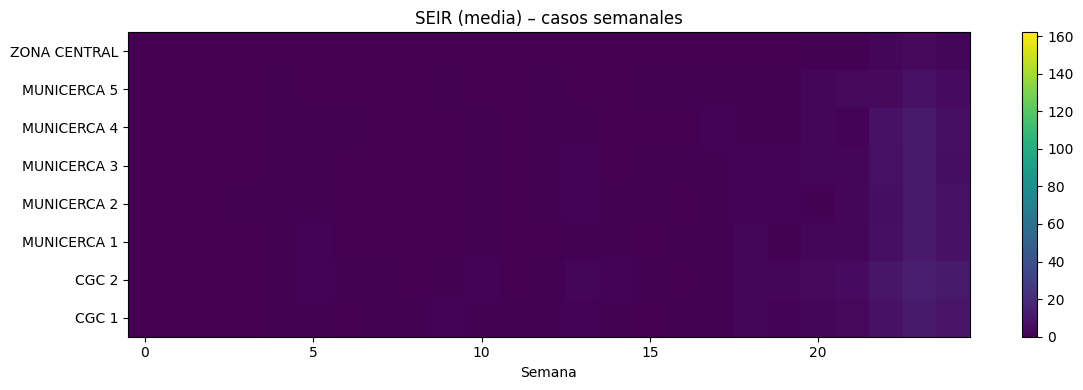

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- utils robustos ----------------
def seir_ensemble_stats(seir_runs, qlo=10, qhi=90):
    arr = np.stack(seir_runs, axis=0)       # (R,W,P)
    mu  = arr.mean(axis=0)                  # (W,P)
    lo  = np.percentile(arr, qlo, axis=0)   # (W,P)
    hi  = np.percentile(arr, qhi, axis=0)   # (W,P)
    return mu, lo, hi

def align_weeks(y_obs, week_index, seir_runs):
    """Corta todo al mismo número de semanas (mínimo común)."""
    W_list = [y_obs.shape[0], len(week_index)] + [Y.shape[0] for Y in seir_runs]
    W = int(min(W_list))
    y_obs2 = y_obs[:W]
    week_index2 = pd.to_datetime(week_index[:W])
    seir_runs2 = [Y[:W] for Y in seir_runs]
    return y_obs2, week_index2, seir_runs2

def align_zones(y_obs, order, seir_runs):
    """Chequea columnas (zonas) y corta si hace falta. Idealmente deben coincidir exactamente."""
    P = y_obs.shape[1]
    P_runs = {Y.shape[1] for Y in seir_runs}
    if len(P_runs) != 1 or (list(P_runs)[0] != P):
        # si difieren, recorta al mínimo común (último recurso)
        Pmin = min([P] + [Y.shape[1] for Y in seir_runs] + [len(order)])
        y_obs = y_obs[:, :Pmin]
        order = list(order)[:Pmin]
        seir_runs = [Y[:, :Pmin] for Y in seir_runs]
    return y_obs, order, seir_runs

def to_df(y, week_index, cols):
    """y: (W,P) -> DataFrame index=week, columns=cols (recorta si hace falta)."""
    W, P = y.shape
    idx = pd.to_datetime(week_index[:W])
    cols = list(cols)[:P]
    return pd.DataFrame(y, index=idx, columns=cols)

# ------------ 1) total ciudad ------------
def plot_total(y_obs, week_index, order, seir_runs):
    # alinear semanas y zonas antes de graficar
    y_obs, week_index, seir_runs = align_weeks(y_obs, week_index, seir_runs)
    y_obs, order, seir_runs = align_zones(y_obs, order, seir_runs)

    mu, lo, hi = seir_ensemble_stats(seir_runs)
    df_o = to_df(y_obs, week_index, order).sum(axis=1)
    df_m = to_df(mu,    week_index, order).sum(axis=1)
    df_l = to_df(lo,    week_index, order).sum(axis=1)
    df_h = to_df(hi,    week_index, order).sum(axis=1)

    common_idx = df_o.index.intersection(df_m.index)
    df_o, df_m, df_l, df_h = df_o.loc[common_idx], df_m.loc[common_idx], df_l.loc[common_idx], df_h.loc[common_idx]

    plt.figure(figsize=(11,4))
    plt.plot(df_o.index, df_o.values, label="Obs (total)")
    plt.plot(df_m.index, df_m.values, label="SEIR (media)")
    plt.fill_between(df_m.index, df_l.values, df_h.values, alpha=0.25, label="SEIR (p10–p90)")
    plt.title("Total semanal")
    plt.xlabel("Semana"); plt.ylabel("Casos")
    plt.legend(); plt.tight_layout(); plt.show()

# ------------ 2) por zona (top-k por casos) ------------
def plot_topk_zones(y_obs, week_index, order, seir_runs, k=6):
    y_obs, week_index, seir_runs = align_weeks(y_obs, week_index, seir_runs)
    y_obs, order, seir_runs = align_zones(y_obs, order, seir_runs)
    mu, lo, hi = seir_ensemble_stats(seir_runs)

    df_o = to_df(y_obs, week_index, order)
    df_m = to_df(mu,    week_index, order)
    df_l = to_df(lo,    week_index, order)
    df_h = to_df(hi,    week_index, order)

    topk = df_o.sum(0).sort_values(ascending=False).head(k).index.tolist()
    common_idx = df_o.index.intersection(df_m.index)
    df_o, df_m, df_l, df_h = df_o.loc[common_idx, topk], df_m.loc[common_idx, topk], df_l.loc[common_idx, topk], df_h.loc[common_idx, topk]

    rows = int(np.ceil(k/3)); cols = min(3, k)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for i, z in enumerate(topk):
        ax = axes[i]
        ax.plot(df_o.index, df_o[z].values, label="Obs")
        ax.plot(df_m.index, df_m[z].values, label="SEIR")
        ax.fill_between(df_m.index, df_l[z].values, df_h[z].values, alpha=0.25)
        ax.set_title(z)
    for ax in axes[k:]: ax.axis("off")
    axes[0].legend()
    fig.suptitle(f"SEIR vs Obs por zona (top {k})", y=1.02)
    plt.tight_layout(); plt.show()

# ------------ 3) heatmaps (obs vs modelo) ------------
def plot_heatmaps(y_obs, week_index, order, seir_runs):
    y_obs, week_index, seir_runs = align_weeks(y_obs, week_index, seir_runs)
    y_obs, order, seir_runs = align_zones(y_obs, order, seir_runs)
    mu, _, _ = seir_ensemble_stats(seir_runs)

    df_o = to_df(y_obs, week_index, order)
    df_m = to_df(mu,    week_index, order)
    common_idx = df_o.index.intersection(df_m.index)
    df_o, df_m = df_o.loc[common_idx], df_m.loc[common_idx]

    vmax = max(df_o.values.max(), df_m.values.max())

    plt.figure(figsize=(12,4))
    plt.imshow(df_o.values.T, aspect="auto", origin="lower", vmin=0, vmax=vmax)
    plt.yticks(range(len(order)), order)
    plt.title("Observado – casos semanales"); plt.xlabel("Semana"); plt.colorbar(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(12,4))
    plt.imshow(df_m.values.T, aspect="auto", origin="lower", vmin=0, vmax=vmax)
    plt.yticks(range(len(order)), order)
    plt.title("SEIR (media) – casos semanales"); plt.xlabel("Semana"); plt.colorbar(); plt.tight_layout(); plt.show()
plot_total(y_obs, week_index, order, seir_runs)
plot_topk_zones(y_obs, week_index, order, seir_runs, k=6)
plot_heatmaps(y_obs, week_index, order, seir_runs)
